# SFR kink-fade — the curve-fit lead, swept properly

**Follow-up to** `sfr_kink_fade_backtest.ipynb`, which found that the FOMC
meeting calendar explains 1–6% of a butterfly's variance and that the *real*
effect is smoothing: the residual of **any** smoother mean-reverts where the
raw fly does not, and a plain **cubic spline in slot index** beat every meeting
basis on grid median, positive-config share and Sharpe.

That notebook found it as a *control*, so it never swept it. Three things were
never tested together and are tested here:

1. **The standardisation.** A residual's zero is a fitted fair value, so
   dividing by a trailing sd and **keeping that zero** (`scale_only_zscore`) is
   a different signal from a full trailing z-score, which throws the model's
   zero away and re-centres on a rolling mean. The pairing of `scale`
   standardisation with the **`z0` exit** — "exit when the residual reaches
   zero", i.e. *exit at fitted fair value* — is what produced the winning
   configs, and it was never a grid axis.
2. **The spacing.** The prior labs only ever built 3m and 6m flies. A 6m fly
   carries 2.9× the dispersion of a 3m fly for the *identical* four-contract
   cost, which is the only lever found so far that moves the cost-to-move
   ratio. 9m and 12m flies are now built and are tested here for the first
   time.
3. **The functional form**, on the same footing as everything else rather than
   fixed at whatever the last notebook used.

The instrument is **chosen by the pond test**, not asserted: whichever spacing
has the largest oracle bound net of the round trip gets the full treatment.

In [1]:
CONFIG = dict(
    spacings=("3m", "6m", "9m", "12m"),
    window="liquid16",                  # 2022+, the only honest 16-slot window
    long_window="front8",               # 2019+, regime-rich but thin at 9m/12m
    forms=("ns", "nss", "spline", "poly3"),
    grid_forms=("spline", "nss"),
    cost_bp=2.0,                        # 4 contracts x 2 sides x 0.25bp
    cost_curve=(0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 4.0),
    n_packages=100,
    windows=(60, 120, 250),
    standardisations=("scale", "z"),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "t10", "t21", "t42"),
    directions=("fade", "momentum"),
    max_hold=63,
    lag=1,
    horizons=(5, 10, 21),
)
CONFIG

{'spacings': ('3m', '6m', '9m', '12m'),
 'window': 'liquid16',
 'long_window': 'front8',
 'forms': ('ns', 'nss', 'spline', 'poly3'),
 'grid_forms': ('spline', 'nss'),
 'cost_bp': 2.0,
 'cost_curve': (0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 4.0),
 'n_packages': 100,
 'windows': (60, 120, 250),
 'standardisations': ('scale', 'z'),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 't10', 't21', 't42'),
 'directions': ('fade', 'momentum'),
 'max_hold': 63,
 'lag': 1,
 'horizons': (5, 10, 21)}

In [2]:
import sys
import time
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig
from RVUtils.MeanRev.signals import (
    curvefit_residual_signal, scale_only_zscore, zscore_signal,
)

import sfr_kink_fade_common as K

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

T0 = time.time()
BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
print(f"taker round trip {CONFIG['cost_bp']}bp on the package "
      f"({CONFIG['n_packages']} packages = {4 * CONFIG['n_packages']:,} contracts "
      f"= ${25 * CONFIG['n_packages']:,}/bp)")
print(f"results -> {K.DATA_DIR}")

taker round trip 2.0bp on the package (100 packages = 400 contracts = $2,500/bp)
results -> C:\Users\chris\clee\ARBS\notebooks\data\sfr_kink_fade


## 1. Four spacings, one cost

Every one of these is a `1/-2/1` package: **four contracts, 2.0bp round trip,
$25 per bp of fly.** The only thing that changes with the spacing is how far
the thing moves. That is the whole reason to look.

In [3]:
labs = {}
for sp in CONFIG["spacings"]:
    labs[sp] = K.load_lab(sp, CONFIG["window"])
    lv = labs[sp]["levels"]
    print(f"{sp:>4}: {lv.shape[1]:2d} flies x {lv.shape[0]} sessions   "
          f"{lv.index.min().date()} -> {lv.index.max().date()}")

rows = []
for sp, lab in labs.items():
    lv = lab["levels"]
    st = lab["struct"]
    d = lv.diff().stack()
    rows.append({
        "spacing": sp, "n_keys": lv.shape[1],
        "pooled_sd_bp": float(lv.stack().std()),
        "daily_sd_bp": float(d.std()),
        "sd_in_ticks": float(lv.stack().std() / 0.5),
        "iqr_bp": float(lv.stack().quantile(0.75) - lv.stack().quantile(0.25)),
        "pct_unchanged_day": float((d.abs() < 1e-9).mean()),
        "round_trip_bp": CONFIG["cost_bp"],
        "cost_in_daily_sd": CONFIG["cost_bp"] / float(d.std()),
    })
disp = pd.DataFrame(rows)
print("\nDISPERSION PER SPACING (all four cost exactly 2.0bp to trade)")
print(disp.round(3).to_string(index=False))
print("\n  `sd_in_ticks` is the honest lattice check: the SR3 settlement grid is")
print("  0.5bp, so a structure whose sd is a handful of ticks is a lattice, not a")
print("  price series. `cost_in_daily_sd` is how many days of typical movement")
print("  the round trip costs -- lower is better and it is the only number here")
print("  that a wider spacing can improve for free.")

  3m: 32 flies x 1149 sessions   2022-01-03 -> 2026-07-29
  6m: 30 flies x 1149 sessions   2022-01-03 -> 2026-07-29


  9m: 28 flies x 1149 sessions   2022-01-03 -> 2026-07-29


 12m: 26 flies x 1149 sessions   2022-01-03 -> 2026-07-29

DISPERSION PER SPACING (all four cost exactly 2.0bp to trade)
spacing  n_keys  pooled_sd_bp  daily_sd_bp  sd_in_ticks  iqr_bp  pct_unchanged_day  round_trip_bp  cost_in_daily_sd
     3m      32         6.873        0.960       13.745     3.0              0.376            2.0             2.084
     6m      30        19.998        2.301       39.997    12.5              0.202            2.0             0.869
     9m      28        34.075        3.647       68.149    27.5              0.141            2.0             0.548
    12m      26        46.644        4.796       93.287    49.5              0.095            2.0             0.417

  `sd_in_ticks` is the honest lattice check: the SR3 settlement grid is
  0.5bp, so a structure whose sd is a handful of ticks is a lattice, not a
  price series. `cost_in_daily_sd` is how many days of typical movement
  the round trip costs -- lower is better and it is the only number here
  that

## 2. The curve fits

Fit a smooth function of maturity to the 16-slot strip on each date and take
each contract's deviation. The fit is **cross-sectional on that date only**, so
it carries no time-series look-ahead by construction — no window, no burn-in.

A butterfly is already a second difference along the strip and a smooth curve
has small second differences by design, so the residual of a smooth fit is
*almost* the fly again. The diagnostic measures exactly how much.

In [4]:
slot_panel = labs["3m"]["slot_panel"]
_RESID = {}


def resid_slots(form):
    """Per-slot residual panel, memoised. One fit per date, shared by every
    spacing -- the strip does not know how far apart a fly's legs are."""
    if form not in _RESID:
        t = time.time()
        # struct only supplies leg slots for the mapping; ask for the raw slot
        # residual by mapping onto the 3m frame and inverting is fragile, so the
        # panel is built directly here and combined per spacing below.
        from RVUtils.curve_fit_rv import _ns_yield, _nss_yield
        from scipy.interpolate import LSQUnivariateSpline
        from scipy.optimize import least_squares

        P = slot_panel.dropna(axis=1, how="all").sort_index()
        cols = list(P.columns)
        x = np.array([float(c) / 4.0 for c in cols])
        arr = P[cols].to_numpy(dtype=float)
        out = np.full(arr.shape, np.nan)
        warm = None
        for i in range(arr.shape[0]):
            y = arr[i]
            ok = np.isfinite(y)
            if ok.sum() < 6:
                continue
            xf, yf = x[ok], y[ok]
            try:
                if form in ("ns", "nss"):
                    fn = _ns_yield if form == "ns" else _nss_yield
                    cold = ([yf[-1], yf[0] - yf[-1], 0.0, 2.0] if form == "ns"
                            else [yf[-1], yf[0] - yf[-1], 0.0, 0.0, 2.0, 5.0])
                    p0 = warm if warm is not None and len(warm) == len(cold) else cold
                    with np.errstate(over="ignore", invalid="ignore"):
                        res = least_squares(lambda p: fn(xf, *p) - yf, p0, max_nfev=200)
                        if not res.success:
                            res = least_squares(lambda p: fn(xf, *p) - yf, cold,
                                                max_nfev=800)
                        warm = res.x if res.success else None
                        fit = fn(x, *res.x)
                elif form == "spline":
                    fit = LSQUnivariateSpline(xf, yf, t=np.quantile(xf, [0.33, 0.66]),
                                              k=3)(x)
                else:
                    fit = np.polyval(np.polyfit(xf, yf, 3), x)
            except Exception:
                continue
            out[i] = (y - fit) * 100.0          # bp
        _RESID[form] = pd.DataFrame(out, index=P.index, columns=cols)
        print(f"  built {form} slot residual in {time.time() - t:.1f}s")
    return _RESID[form]


def resid_fly(lab, form):
    from RVUtils.MeanRev.signals import structure_signal_from_slots

    L = lab["levels"]
    return structure_signal_from_slots(resid_slots(form), lab["struct"],
                                       scale=1.0).reindex(index=L.index,
                                                          columns=L.columns)


rows = []
for form in CONFIG["forms"]:
    for sp, lab in labs.items():
        r = resid_fly(lab, form)
        lv = lab["levels"]
        corr = pd.Series({c: lv[c].corr(r[c]) for c in lv.columns})
        rows.append({"form": form, "spacing": sp,
                     "resid_sd_bp": float(r.stack().std()),
                     "raw_sd_bp": float(lv.stack().std()),
                     "resid_share_of_sd": float(r.stack().std() / lv.stack().std()),
                     "median_corr_with_raw": float(corr.median())})
fits = pd.DataFrame(rows)
print("\nRESIDUAL vs RAW FLY, per form and spacing")
print(fits.round(3).to_string(index=False))
print("\n  median_corr_with_raw near 1.0 would mean the 'curve residual' IS the")
print("  fly and this whole framework collapses into a z-score notebook.")
fits.to_csv(K.DATA_DIR / "curvefit_forms.csv", index=False)

  built ns slot residual in 2.0s


  built nss slot residual in 53.6s
  built spline slot residual in 0.1s


  built poly3 slot residual in 0.0s

RESIDUAL vs RAW FLY, per form and spacing
  form spacing  resid_sd_bp  raw_sd_bp  resid_share_of_sd  median_corr_with_raw
    ns      3m        5.710      6.873              0.831                 0.651
    ns      6m       12.115     19.998              0.606                 0.658
    ns      9m       17.298     34.075              0.508                 0.702
    ns     12m       19.781     46.644              0.424                 0.663
   nss      3m        5.251      6.873              0.764                 0.649
   nss      6m       13.933     19.998              0.697                 0.558
   nss      9m       20.038     34.075              0.588                 0.579
   nss     12m       21.560     46.644              0.462                 0.629
spline      3m        2.491      6.873              0.362                 0.443
spline      6m        4.459     19.998              0.223                 0.168
spline      9m        4.929     34.075   

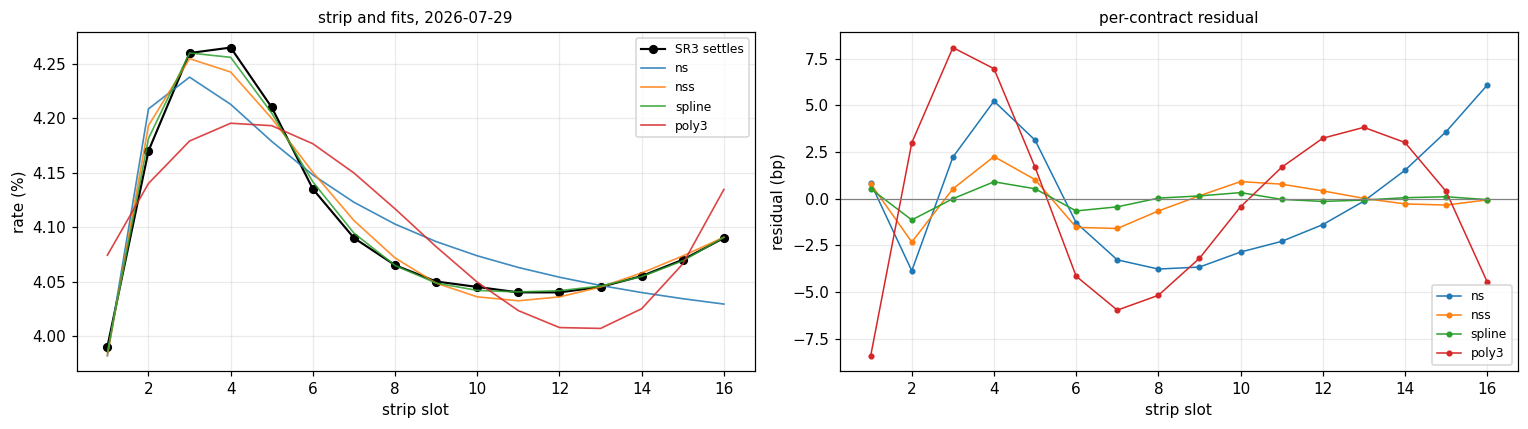

In [5]:
d = slot_panel.dropna().index[-1]
y = slot_panel.loc[d].dropna()
x = np.array([int(c) for c in y.index])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(x, y.to_numpy(), "o-", color="black", lw=1.4, ms=5, label="SR3 settles")
for form in CONFIG["forms"]:
    r = resid_slots(form)
    axes[0].plot(x, y.to_numpy() - r.loc[d, x].to_numpy() / 100.0, lw=1.1,
                 alpha=0.85, label=form)
    axes[1].plot(x, r.loc[d, x].to_numpy(), "o-", lw=1.0, ms=3, label=form)
axes[0].set_xlabel("strip slot")
axes[0].set_ylabel("rate (%)")
axes[0].set_title(f"strip and fits, {pd.Timestamp(d).date()}", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_xlabel("strip slot")
axes[1].set_ylabel("residual (bp)")
axes[1].set_title("per-contract residual", fontsize=10)
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. The pond test picks the instrument

Before any grid: on the days each signal fires, how far does the structure
actually move? `oracle_net_bp` is what a trader with perfect foresight of the
**direction** would capture net of the 2.0bp round trip — a ceiling no signal
work can exceed. A spacing whose ceiling is negative cannot be rescued by a
better kink definition, and the 3m fly is exactly that.

In [6]:
PRIMARY_FORM = "spline"
ponds = []
for sp, lab in labs.items():
    lv = lab["levels"]
    r = resid_fly(lab, PRIMARY_FORM)
    sig = {
        f"{sp} raw z": zscore_signal(lv, window=120),
        f"{sp} spline resid (scale)": scale_only_zscore(r, window=120),
        f"{sp} spline resid (z)": zscore_signal(r, window=120),
    }
    t = K.selectivity_table(lv, sig, entry_z=2.0, gate=lab["gate"],
                            horizons=CONFIG["horizons"],
                            round_trip_bp=CONFIG["cost_bp"])
    t.insert(0, "spacing", sp)
    ponds.append(t)
pond = pd.concat(ponds, ignore_index=True)
pond.to_csv(K.DATA_DIR / "curvefit_pond.csv", index=False)
print("POND TEST across spacings (entry |z| >= 2.0, round trip 2.0bp)")
print(pond[pond["horizon"] == 21].round(3).to_string(index=False))

POND TEST across spacings (entry |z| >= 2.0, round trip 2.0bp)
spacing                   signal  horizon     n  mean_abs_bp  selectivity  median_abs_bp  p90_abs_bp  oracle_net_bp  p_beat_cost  mean_bp  sd_bp
     3m            unconditional       21 15414        1.774        1.000           0.75        4.50         -0.226        0.237    0.275  3.382
     3m                 3m raw z       21  2145        2.454        1.383           1.00        6.50          0.454        0.339    0.276  4.237
     3m  3m spline resid (scale)       21  2757        2.768        1.560           1.00        7.50          0.768        0.355    0.251  4.882
     3m      3m spline resid (z)       21  1723        2.654        1.496           1.00        7.50          0.654        0.332    0.075  4.790
     6m            unconditional       21 13158        5.103        1.000           2.00       13.50          3.103        0.516    0.515  9.373
     6m                 6m raw z       21  2157        6.305       

In [7]:
h = 21
best_by_spacing = (pond[(pond["horizon"] == h) & (pond["signal"] != "unconditional")]
                   .groupby("spacing")["oracle_net_bp"].max().sort_values(ascending=False))
print(f"\nbest oracle_net_bp at h={h} by spacing (bp per trade, net of 2.0bp):")
print(best_by_spacing.round(3).to_string())
PRIMARY = str(best_by_spacing.index[0])
print(f"\n  -> PRIMARY SPACING CHOSEN BY MEASUREMENT: {PRIMARY}")
print(f"     ({best_by_spacing.iloc[0]:+.2f}bp of headroom against a 2.0bp round trip)")
viable = [s for s in best_by_spacing.index if best_by_spacing[s] > 0]
print(f"     spacings whose oracle clears the round trip at all: {viable}")


best oracle_net_bp at h=21 by spacing (bp per trade, net of 2.0bp):
spacing
12m    11.623
9m      8.418
6m      4.305
3m      0.768

  -> PRIMARY SPACING CHOSEN BY MEASUREMENT: 12m
     (+11.62bp of headroom against a 2.0bp round trip)
     spacings whose oracle clears the round trip at all: ['12m', '9m', '6m', '3m']


## 4. The sweep that was never run

`standardise` is a grid axis for the first time, so "keep the fitted model's
zero" versus "re-centre on a trailing mean" is a measurement rather than a
choice — and `exit_style='z0'` means different things under the two. Under
`scale` it is *exit at fitted fair value*; under `z` it is *exit at the
trailing mean of the residual*.


### GRID  (26 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/288 configs


  50/288 configs


  75/288 configs


  100/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -275.75bp | IQR [-572.50, -8.25] | 24% net-positive | best +666.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline     120       scale      1.5         z0      fade       156     0.500       4.271        666.25      1665625.0   0.840    -259.50
spline     250       scale      1.5         z0      fade        94     0.500       5.646        530.75      1326875.0   0.813    -214.50
spline     250       scale      1.5        t42      fade        90     0.478       5.683        511.50      1278750.0   0.760    -182.00
spline     120       scale      1.5        t42      fade       131     0.458       3.811        499.25      1248125.0   0.735    -270.50
   nss     120           z      1.5        t42  momentum       131     0.481       3.752        491.50      1228750.0   0.505    -447.50
spline     120  

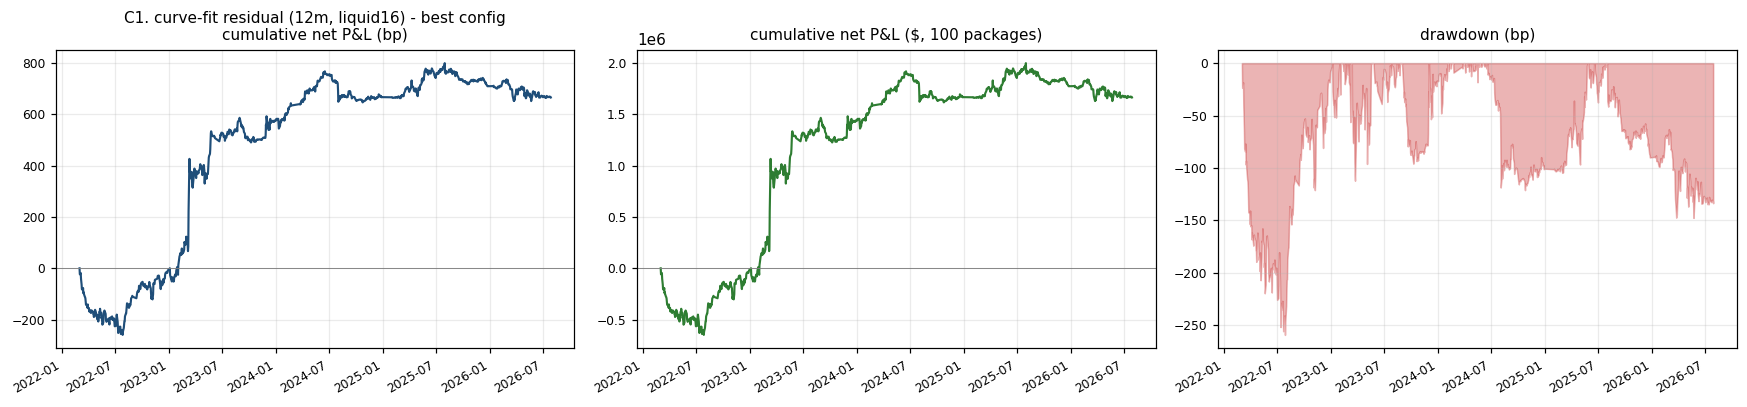


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd    exit_reason
H22-H23-H24   -1  2022-03-01 2022-03-02 2022-03-15     9  2.808    124.25     156.00    -31.75      2.0  -33.75  -84375.0       max_hold
H23-H24-H25    1  2022-03-01 2022-03-02 2022-06-01    63 -3.296     15.50      -4.50    -20.00      2.0  -22.00  -55000.0       max_hold
Z23-Z24-Z25   -1  2022-03-01 2022-03-02 2022-06-01    63  2.352    -14.50     -14.50     -0.00      2.0   -2.00   -5000.0       max_hold
M23-M24-M25    1  2022-03-01 2022-03-02 2022-06-01    63 -5.699     -8.50     -21.50    -13.00      2.0  -15.00  -37500.0       max_hold
M22-M23-M24   -1  2022-03-02 2022-03-03 2022-06-02    63  1.632    110.00     192.25    -82.25      2.0  -84.25 -210625.0       max_hold
Z22-Z23-Z24   -1  2022-03-03 2022-03-04 2022-03-10     4  1.670     47.00      53.50     -6.50      2.0   -8.50  -21250.0 mean_reversion
U23-U24-U25   


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       156           978.2         666.2       4.271     0.500   0.840     -259.5      29.7          False             False
         belly       1            1            0.5       156           573.0         495.0       3.173     0.558   0.793     -192.5      29.7          False             False
belly_vs_front       2            2            1.0       156           646.2         490.2       3.143     0.558   0.818     -246.0      29.7          False             False
 belly_vs_back       2            2            1.0       156           332.0         176.0       1.128     0.481   0.563      -71.5      29.7          False             False
  -> fly beats every linear shadow on net bp
C1. cur

In [8]:
GRID = {"form": CONFIG["grid_forms"], "window": CONFIG["windows"],
        "standardise": CONFIG["standardisations"], "entry_z": CONFIG["entry_zs"],
        "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS = ["form", "window", "standardise", "entry_z", "exit_style", "direction"]
EXITS = ("z0", "band", "t5", "t10", "t21", "t42")

lab_p = labs[PRIMARY]


def cf_sig(L, form, window, standardise):
    r = resid_fly(lab_p, form).reindex(index=L.index, columns=L.columns)
    return (scale_only_zscore(r, window=window) if standardise == "scale"
            else zscore_signal(r, window=window))


out_main = K.run_family(f"C1. curve-fit residual ({PRIMARY}, {CONFIG['window']})",
                        lab=lab_p, signal_fn=cf_sig, grid_spec=GRID, params=PARAMS,
                        base=BASE, cls="curvefit",
                        note="standardisation swept: model's zero vs trailing mean",
                        exits=EXITS)

### 4a. Does keeping the model's zero actually matter?

In [9]:
g = out_main["grid"]
std_split = (g.groupby("standardise")
             .agg(n_configs=("total_net_bp", "size"),
                  median_net_bp=("total_net_bp", "median"),
                  pct_positive=("total_net_bp", lambda s: float((s > 0).mean())),
                  best_net_bp=("total_net_bp", "max"),
                  median_trades=("n_trades", "median")))
print("STANDARDISATION (the axis this notebook exists to test)")
print(std_split.round(3).to_string())

pair = (g.groupby(["standardise", "exit_style"])["total_net_bp"]
        .median().unstack().round(1))
print("\nmedian net bp by standardisation x exit -- the pairing under test is "
      "(scale, z0) = 'exit at fitted fair value':")
print(pair.to_string())
best_cell = pair.stack().idxmax()
print(f"\n  best cell: standardise={best_cell[0]}, exit={best_cell[1]} "
      f"({pair.loc[best_cell[0], best_cell[1]]:+.1f}bp median)")
std_split.to_csv(K.DATA_DIR / "curvefit_standardisation.csv")

STANDARDISATION (the axis this notebook exists to test)
             n_configs  median_net_bp  pct_positive  best_net_bp  median_trades
standardise                                                                    
scale              144       -289.125         0.208       666.25          136.5
z                  144       -266.625         0.278       491.50          119.0

median net bp by standardisation x exit -- the pairing under test is (scale, z0) = 'exit at fitted fair value':
exit_style     t10    t21    t42     z0
standardise                            
scale       -556.6 -302.5 -166.2 -170.5
z           -373.4 -170.6 -125.5 -180.1

  best cell: standardise=z, exit=t42 (-125.5bp median)


## 5. Every spacing, same grid

League rows so the four spacings rank against each other and against the
meeting-residual rows from the main kink notebook.


### GRID  (32 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/288 configs


  50/288 configs


  75/288 configs


  100/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -562.62bp | IQR [-833.81, -369.19] | 0% net-positive | best -86.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline     250       scale      2.5         z0      fade        92     0.315      -0.940        -86.50      -216250.0  -0.665    -137.75
spline     250       scale      2.5        t42      fade        96     0.250      -0.909        -87.25      -218125.0  -0.598    -131.75
   nss     250       scale      2.5         z0      fade       106     0.292      -0.983       -104.25      -260625.0  -0.413    -169.50
spline     250           z      2.5         z0      fade        92     0.293      -1.188       -109.25      -273125.0  -0.841    -133.25
spline     250           z      2.5        t42      fade        93     0.226      -1.301       -121.00      -302500.0  -0.820    -143.00
   nss     250  

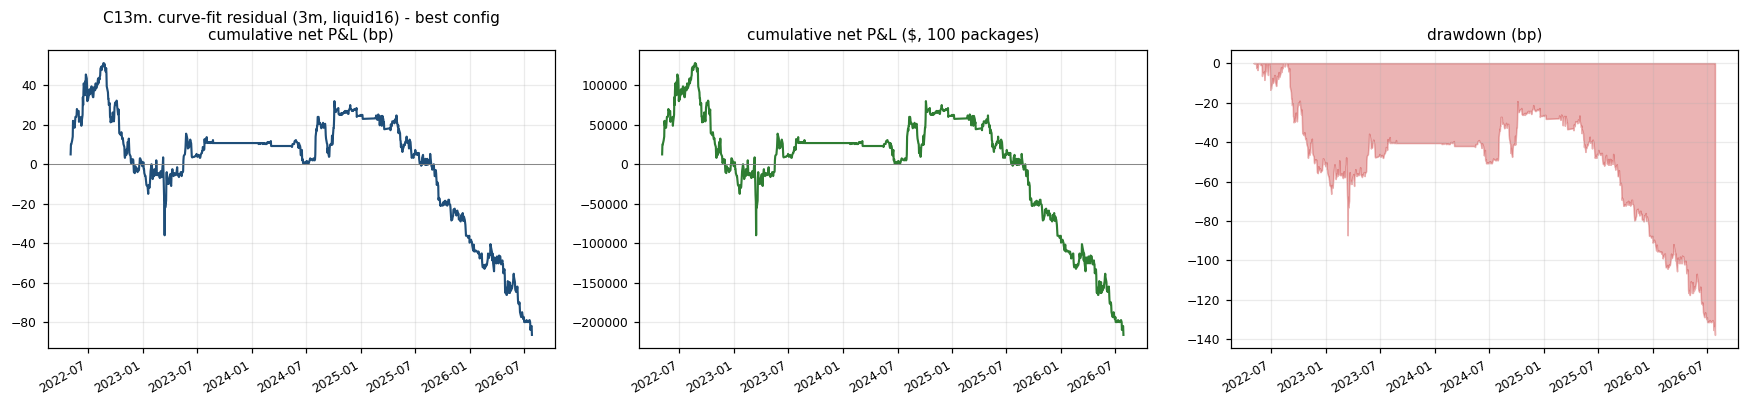


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
H23-M23-U23   -1  2022-05-02 2022-05-03 2022-06-14    29  2.935      17.0       8.50      8.50      2.0    6.50  16250.0 mean_reversion
U22-Z22-H23    1  2022-05-02 2022-05-03 2022-06-16    31 -4.133      12.5      39.00     26.50      2.0   24.50  61250.0 mean_reversion
M22-U22-Z22   -1  2022-05-02 2022-05-03 2022-05-20    13  2.574      42.5      31.50     11.00      2.0    9.00  22500.0 mean_reversion
M25-U25-Z25    1  2022-05-03 2022-05-04 2022-06-21    32 -2.524      -2.5      -2.00      0.50      2.0   -1.50  -3750.0 mean_reversion
Z22-H23-M23   -1  2022-05-20 2022-05-23 2022-07-14    35  3.211      21.5      14.50      7.00      2.0    5.00  12500.0 mean_reversion
H24-M24-U24    1  2022-06-02 2022-06-03 2022-06-15     8 -2.508      -3.5      -2.00      1.50      2.0   -0.50  -1250.0 mean_reversion
H23-M23-U23    1  202

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0        92    35.783     0.315      -0.940        -86.50  -0.665
band       104    26.894     0.269      -0.707        -73.50  -0.586
  t5       280     4.943     0.107      -1.745       -488.50  -5.071
 t10       196     9.796     0.168      -1.478       -289.75  -2.766
 t21       138    20.043     0.232      -1.121       -154.75  -1.138
 t42        96    38.562     0.250      -0.909        -87.25  -0.598

  cost curve (round-trip bp charged on the package):
 round_trip_bp  n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 92          97.5        1.06     0.576       243750.0
           0.5 92          51.5        0.56     0.467       128750.0
           1.0 92           5.5        0.06     0.391        13750.0
           1.5 92         -40.5       -0.44     0.337      -101250.0
           2.0 92         -86.5       -0.94     0.315      -216250.0
           2.5 92        -132.5       -1.44     0

C13m. curve-fit residual (3m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z2.0|t42|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   196   skipped    0   hit 13%   avg -2.878bp   avg hold 40.1d
  total    -564.00bp   $   -1,410,000   gross -172.00bp
  daily-MTM Sharpe -2.94   maxDD -568.25bp ($-1,420,625)   worst trade -32.50bp
  t(trade) -7.54   NW t(daily) -6.32   non-overlap SR -0.17   DSR p=0.000 over 288 trials

  LEAGUE ROW  C13m. curve-fit residual (3m, liquid16) / best-config: MARGINAL-maker-only  (taker -86.50bp, maker +97.50bp, DSR p=0.000)

  LEAGUE ROW  C13m. curve-fit residual (3m, liquid16) / median-config: DEAD  (taker -564.00bp, maker -172.00bp, DSR p=0.000)

### GRID  (30 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/288 configs


  50/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -444.12bp | IQR [-699.69, -225.25] | 5% net-positive | best +155.25bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline     250       scale      2.0        t21      fade       158     0.354       0.983        155.25       388125.0   0.542    -130.25
   nss     250       scale      2.5         z0      fade        79     0.494       1.453        114.75       286875.0   0.200    -295.50
spline     250           z      2.5         z0      fade        62     0.468       1.702        105.50       263750.0   0.580     -51.50
spline     250       scale      2.5        t21      fade        91     0.352       1.019         92.75       231875.0   0.498     -97.25
spline     250           z      2.0         z0      fade       107     0.402       0.839         89.75       224375.0   0.309     -96.50
spline     250 

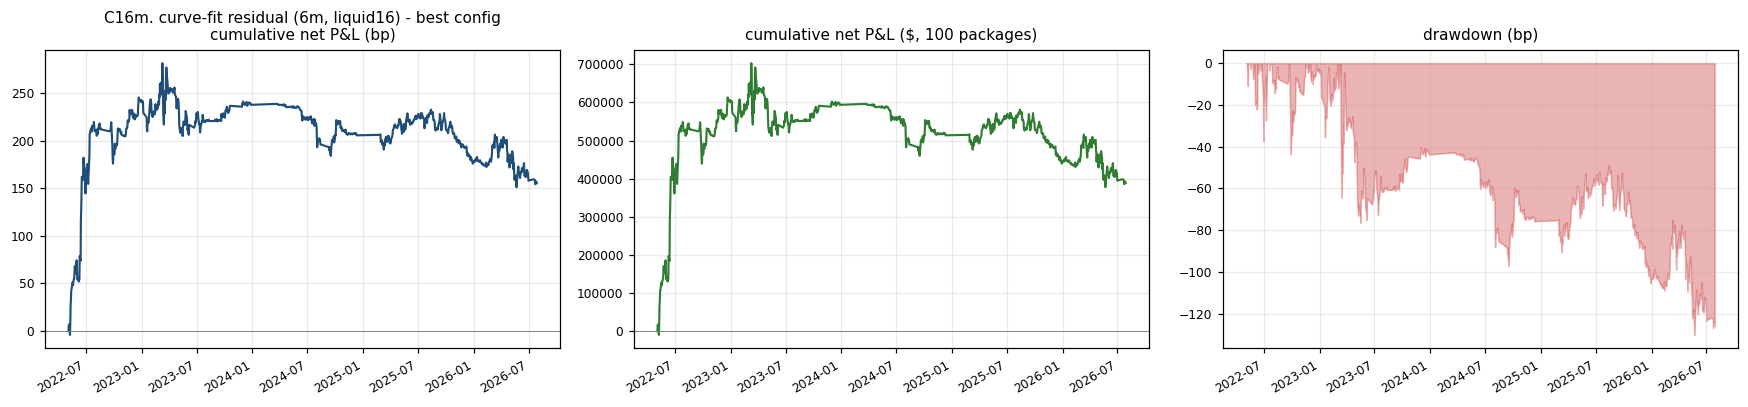


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
H23-U23-H24   -1  2022-05-02 2022-05-03 2022-06-02    21  2.560     30.50      13.50     17.00      2.0   15.00  37500.0        time
Z23-M24-Z24    1  2022-05-02 2022-05-03 2022-06-02    21 -2.102     -9.00      -9.50     -0.50      2.0   -2.50  -6250.0        time
Z22-M23-Z23   -1  2022-05-02 2022-05-03 2022-06-02    21  2.587     59.00      48.50     10.50      2.0    8.50  21250.0        time
H24-U24-H25   -1  2022-05-02 2022-05-03 2022-06-02    21  2.036     -2.00      -6.00      4.00      2.0    2.00   5000.0        time
U23-H24-U24    1  2022-05-02 2022-05-03 2022-06-02    21 -2.216    -11.00      -7.50      3.50      2.0    1.50   3750.0        time
M24-Z24-M25   -1  2022-05-02 2022-05-03 2022-06-02    21  2.069      2.00      -0.50      2.50      2.0    0.50   1250.0        time
M22-Z22-M23    1  2022-05-02 2022-05-03 20


REGIME SPLIT (a single six-year parameter set is the thing being tested)
 regime  n_trades  n_days  hit_rate  avg_net_bp  total_net_bp  total_net_usd  daily_sharpe
   ZIRP         0       0       NaN         NaN          0.00            0.0           NaN
 HIKING        52     271     0.500       4.240        220.50       551250.0         1.565
PLATEAU        13     162     0.231       0.423          5.50        13750.0        -1.216
CUTTING        93     405     0.290      -0.761        -70.75      -176875.0        -0.371

LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0       158           471.2         155.2       0.983     0.354   0.542     -130.3      20.7          False             False
         belly       1            1            0

C16m. curve-fit residual (6m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z2.5|t10|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   167   skipped    0   hit 20%   avg -2.650bp   avg hold 10.0d
  total    -442.50bp   $   -1,106,250   gross -108.50bp
  daily-MTM Sharpe -3.02   maxDD -455.50bp ($-1,138,750)   worst trade -55.00bp
  t(trade) -4.59   NW t(daily) -4.19   non-overlap SR -0.48   DSR p=0.000 over 288 trials

  LEAGUE ROW  C16m. curve-fit residual (6m, liquid16) / best-config: SELECTION-ARTIFACT  (taker +155.25bp, maker +471.25bp, DSR p=0.000)

  LEAGUE ROW  C16m. curve-fit residual (6m, liquid16) / median-config: DEAD  (taker -442.50bp, maker -108.50bp, DSR p=0.000)

### GRID  (28 keys, 1149 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/288 configs


  50/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -359.25bp | IQR [-636.88, -168.62] | 13% net-positive | best +482.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
   nss     120           z      1.5        t42  momentum       163     0.472       2.962        482.75      1206875.0   0.529    -360.75
spline     250       scale      1.5        t42      fade       135     0.430       3.150        425.25      1063125.0   0.566    -221.00
spline     250           z      1.5        t42      fade       132     0.424       3.114        411.00      1027500.0   0.719    -175.25
   nss     120           z      2.5         z0  momentum        81     0.432       3.957        320.50       801250.0   0.642    -230.50
   nss      60           z      2.5         z0  momentum       127     0.370       2.120        269.25       673125.0   0.373    -369.50
   nss      60

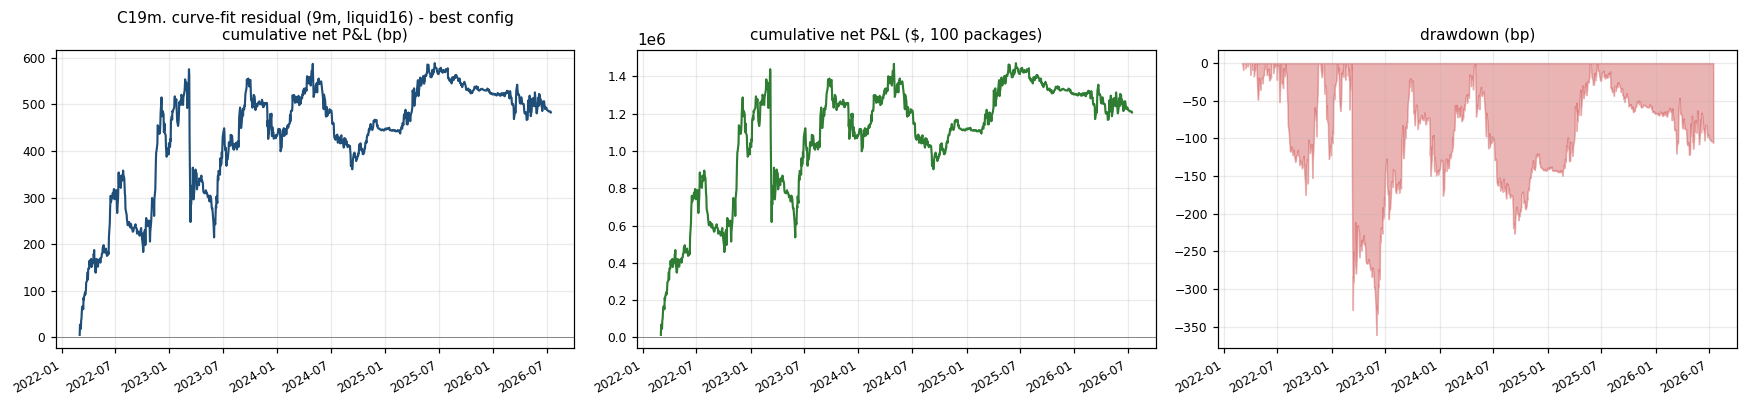


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd exit_reason
Z23-U24-M25   -1  2022-03-01 2022-03-02 2022-05-02    42 -2.612     -13.5      -6.50     -7.00      2.0   -9.00  -22500.0        time
Z22-U23-M24    1  2022-03-01 2022-03-02 2022-05-02    42  1.684      51.5      69.50     18.00      2.0   16.00   40000.0        time
U23-M24-H25   -1  2022-03-01 2022-03-02 2022-05-02    42 -2.267     -11.5     -14.00      2.50      2.0    0.50    1250.0        time
U22-M23-H24    1  2022-03-01 2022-03-02 2022-05-02    42  3.052      66.0     110.00     44.00      2.0   42.00  105000.0        time
M23-H24-Z24   -1  2022-03-01 2022-03-02 2022-05-02    42 -1.655       0.5      -9.00      9.50      2.0    7.50   18750.0        time
H24-Z24-U25    1  2022-03-02 2022-03-03 2022-05-03    42  2.088      -7.0      -0.50      6.50      2.0    4.50   11250.0        time
M24-H25-Z25    1  2022-03-02 2022-0

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       162    37.685     0.370       0.565         91.50   0.087
band       185    29.043     0.303      -0.465        -86.00  -0.084
  t5       630     4.970     0.300      -1.947      -1226.75  -1.490
 t10       421     9.872     0.352      -1.166       -491.00  -0.726
 t21       259    20.595     0.398      -0.306        -79.25  -0.082
 t42       163    40.632     0.472       2.962        482.75   0.529

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 163        808.75       4.962     0.552      2021875.0
           0.5 163        727.25       4.462     0.521      1818125.0
           1.0 163        645.75       3.962     0.515      1614375.0
           1.5 163        564.25       3.462     0.491      1410625.0
           2.0 163        482.75       2.962     0.472      1206875.0
           2.5 163        401.25       2.46

C19m. curve-fit residual (9m, liquid16) - MEDIAN config (the anti-selection control)  |  momentum|z1.5|t21|hold63|lag1|every1|c2.0  |  100 packages ($2,500/bp, 400 contracts)
  trades   329   skipped    2   hit 36%   avg -1.083bp   avg hold 20.6d
  total    -356.25bp   $     -890,625   gross +301.75bp
  daily-MTM Sharpe -0.40   maxDD -894.25bp ($-2,235,625)   worst trade -69.00bp
  t(trade) -1.22   NW t(daily) -0.82   non-overlap SR -0.04   DSR p=0.000 over 288 trials

  LEAGUE ROW  C19m. curve-fit residual (9m, liquid16) / best-config: SELECTION-ARTIFACT  (taker +482.75bp, maker +808.75bp, DSR p=0.006)

  LEAGUE ROW  C19m. curve-fit residual (9m, liquid16) / median-config: MARGINAL-maker-only  (taker -356.25bp, maker +301.75bp, DSR p=0.000)


In [10]:
for sp in CONFIG["spacings"]:
    if sp == PRIMARY:
        continue
    lab_s = labs[sp]

    def cf_sig_s(L, form, window, standardise, _lab=lab_s):
        r = resid_fly(_lab, form).reindex(index=L.index, columns=L.columns)
        return (scale_only_zscore(r, window=window) if standardise == "scale"
                else zscore_signal(r, window=window))

    K.run_family(f"C1{sp}. curve-fit residual ({sp}, {CONFIG['window']})",
                 lab=lab_s, signal_fn=cf_sig_s, grid_spec=GRID, params=PARAMS,
                 base=BASE, cls="curvefit", note=f"{sp} spacing, same grid",
                 exits=EXITS)

## 6. The long window

`front8` starts in 2019 and buys a full policy cycle, but it restricts the back
leg to slot 8 — which at 12m spacing leaves nothing. Whichever spacings survive
that restriction are run; the rest are reported as unavailable rather than
quietly skipped.


3m: 36 keys on front8

### GRID  (36 keys, 1906 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/288 configs


  50/288 configs


  75/288 configs


  100/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -273.88bp | IQR [-405.94, -165.62] | 0% net-positive | best -7.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline     250           z      2.5        t42      fade        54     0.426      -0.130         -7.00       -17500.0  -0.056     -63.50
   nss     250       scale      2.0         z0      fade        76     0.434      -0.237        -18.00       -45000.0  -0.077    -130.75
   nss     250       scale      2.5         z0      fade        57     0.404      -0.338        -19.25       -48125.0  -0.093     -97.00
   nss     120           z      2.5         z0      fade        73     0.397      -0.288        -21.00       -52500.0  -0.141    -110.50
spline      60           z      2.0        t42      fade       107     0.411      -0.234        -25.00       -62500.0  -0.133    -116.25
   nss     250   

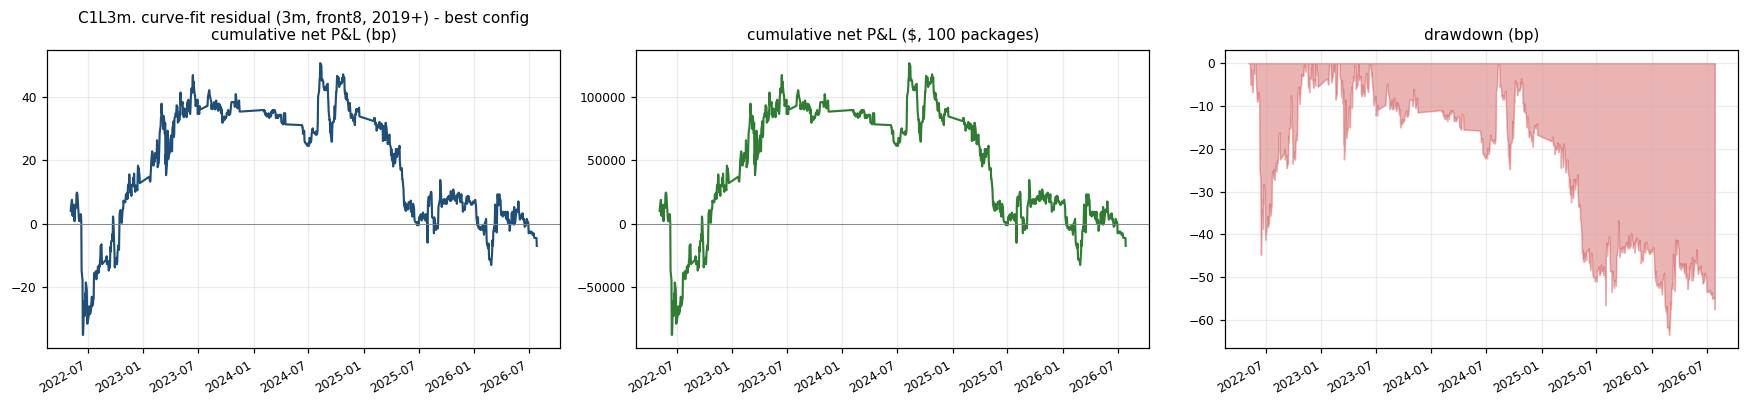


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M22-U22-Z22   -1  2022-05-03 2022-05-04 2022-06-14    28  2.906     37.50      60.00    -22.50      2.0  -24.50 -61250.0        time
Z22-H23-M23   -1  2022-05-24 2022-05-25 2022-07-27    42  2.828     20.00       7.50     12.50      2.0   10.50  26250.0        time
H23-M23-U23    1  2022-06-14 2022-06-15 2022-08-16    42 -2.600      6.50       6.50      0.00      2.0   -2.00  -5000.0        time
U22-Z22-H23   -1  2022-06-15 2022-06-16 2022-08-17    42  3.525     39.00      33.75      5.25      2.0    3.25   8125.0        time
Z22-H23-M23    1  2022-08-29 2022-08-30 2022-10-28    42 -2.877     15.50      37.00     21.50      2.0   19.50  48750.0        time
U22-Z22-H23   -1  2022-09-13 2022-09-14 2022-09-20     4  2.536     64.75      62.75      2.00      2.0   -0.00     -0.0        time
Z22-H23-M23   -1  2022-10-31 2022-11-01 20


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        54           101.0          -7.0      -0.130     0.426  -0.056      -63.5      37.2          False             False
         belly       1            1            0.5        54            68.0          41.0       0.759     0.519   0.091     -201.0      37.2           True              True
belly_vs_front       2            2            1.0        54            67.0          13.0       0.241     0.519   0.075      -85.0      37.2           True              True
 belly_vs_back       2            2            1.0        54            34.0         -20.0      -0.370     0.407  -0.154      -84.0      37.2          False             False
  -> SHADOWED - a simpler instrument beats the fly o

  25/288 configs


  50/288 configs


  75/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -151.62bp | IQR [-268.81, -45.19] | 17% net-positive | best +191.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
spline     250           z      1.5        t42      fade        49     0.449       3.898        191.00       477500.0   0.644    -128.00
   nss      60           z      2.0        t42  momentum        71     0.549       2.539        180.25       450625.0   0.382    -202.75
   nss      60       scale      2.5         z0      fade        62     0.500       2.387        148.00       370000.0   0.291    -176.50
   nss      60           z      1.5        t42  momentum        86     0.523       1.468        126.25       315625.0   0.212    -286.75
spline     250       scale      1.5        t42      fade        46     0.478       2.332        107.25       268125.0   0.339    -140.00
   nss      60 

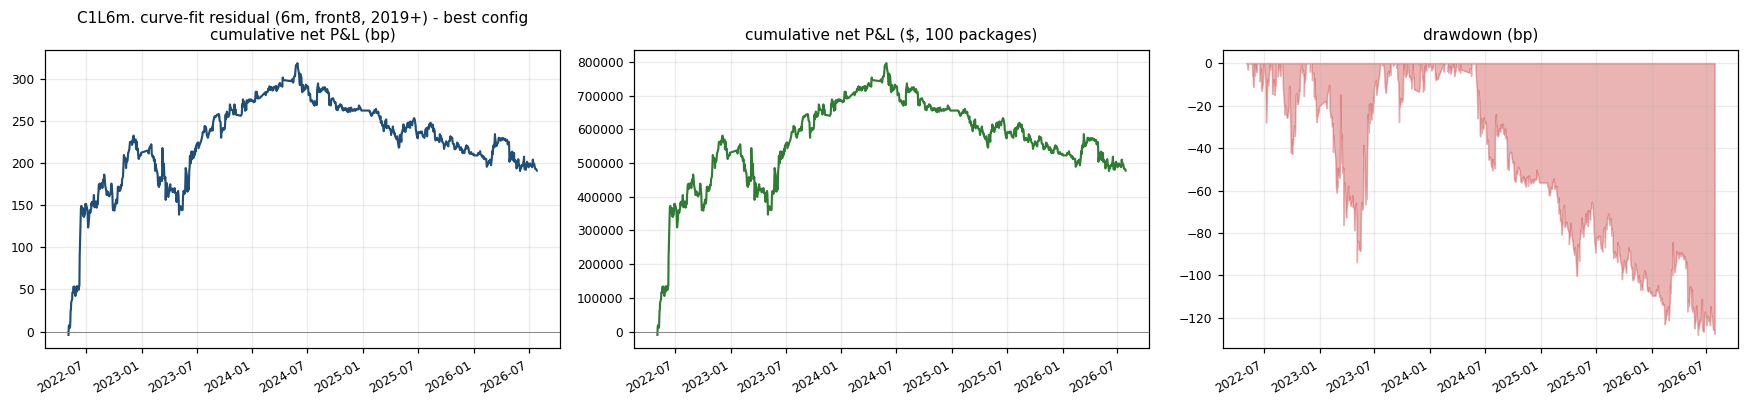


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd exit_reason
U22-H23-U23    1  2022-05-02 2022-05-03 2022-07-05    42 -1.829     64.50      72.00      7.50      2.0    5.50   13750.0        time
Z22-M23-Z23   -1  2022-05-05 2022-05-06 2022-07-08    42  1.518     61.50      28.00     33.50      2.0   31.50   78750.0        time
M22-Z22-M23    1  2022-05-06 2022-05-09 2022-06-14    25 -1.718     71.50     164.50     93.00      2.0   91.00  227500.0        time
U22-H23-U23   -1  2022-07-06 2022-07-07 2022-09-06    42  1.693     80.50      87.00     -6.50      2.0   -8.50  -21250.0        time
Z22-M23-Z23    1  2022-07-11 2022-07-12 2022-09-09    42 -2.231     11.00      34.50     23.50      2.0   21.50   53750.0        time
H23-U23-H24    1  2022-07-14 2022-07-15 2022-09-14    42 -1.510     -9.50      12.50     22.00      2.0   20.00   50000.0        time
Z22-M23-Z23    1  2022-09-13 2022-0


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        49           289.0         191.0       3.898     0.449   0.644     -128.0      36.6          False             False
         belly       1            1            0.5        49           225.5         201.0       4.102     0.469   0.303     -399.5      36.6           True             False
belly_vs_front       2            2            1.0        49           -18.0         -67.0      -1.367     0.388  -0.199     -209.5      36.6          False             False
 belly_vs_back       2            2            1.0        49           307.0         258.0       5.265     0.571   1.064      -77.0      36.6           True              True
  -> SHADOWED - a simpler instrument beats the fly o


9m: 32 keys on front8

### GRID  (32 keys, 1906 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/288 configs


  50/288 configs


...

  200/288 configs


  225/288 configs


  250/288 configs


  275/288 configs


  288 configs | median -33.62bp | IQR [-195.00, +56.81] | 35% net-positive | best +335.00bp

  top rows (SELECTION-INFLATED - read the distribution above first):
  form  window standardise  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
   nss     120           z      1.5         z0  momentum        36     0.556       9.306        335.00       837500.0   0.614    -302.75
spline     120       scale      2.0        t42      fade        22     0.455      14.239        313.25       783125.0   1.045    -109.25
   nss      60           z      2.5         z0  momentum        25     0.560      12.330        308.25       770625.0   1.097    -141.00
spline     120       scale      2.5        t42      fade        18     0.667      17.083        307.50       768750.0   1.149     -83.00
   nss     120           z      1.5        t42  momentum        31     0.613       8.774        272.00       680000.0   0.503    -298.50
   nss     250  

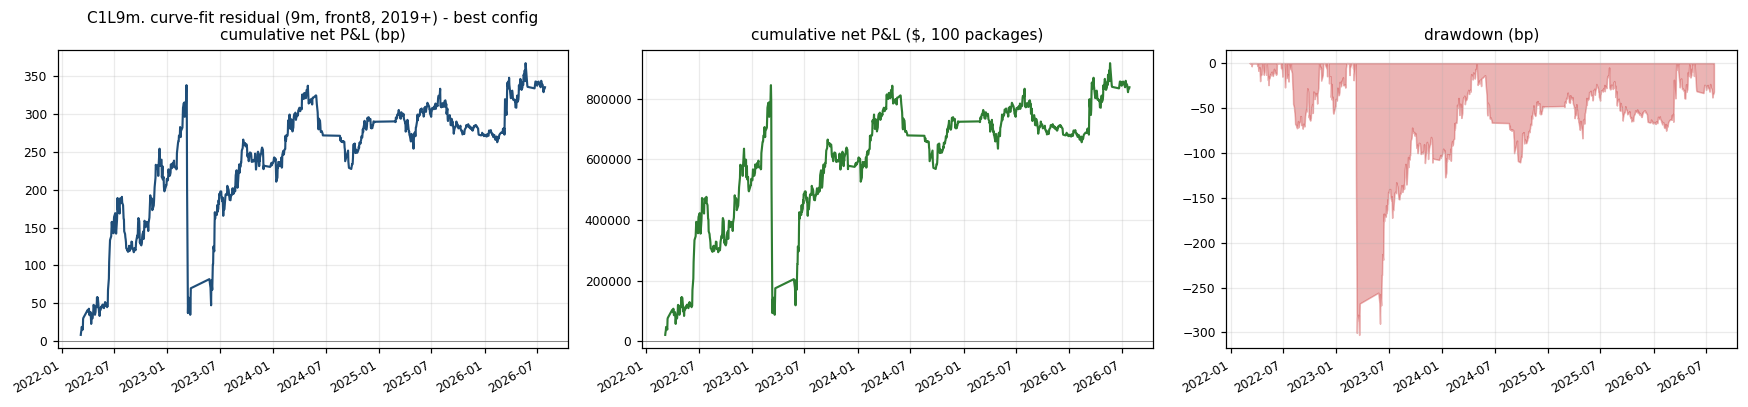


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp   net_usd    exit_reason
M22-H23-Z23    1  2022-03-04 2022-03-07 2022-03-17     8  1.538     69.50     102.50     33.00      2.0   31.00   77500.0 mean_reversion
M22-H23-Z23    1  2022-03-30 2022-03-31 2022-06-14    51  1.739    134.50     243.50    109.00      2.0  107.00  267500.0       max_hold
U22-M23-H24   -1  2022-05-11 2022-05-12 2022-08-12    63 -1.647     87.00     100.50    -13.50      2.0  -15.50  -38750.0       max_hold
Z22-U23-M24    1  2022-08-11 2022-08-12 2022-11-10    63  2.021     37.50      90.00     52.50      2.0   50.50  126250.0       max_hold
Z22-U23-M24    1  2022-11-11 2022-11-14 2022-12-20    25  2.214    107.25     124.50     17.25      2.0   15.25   38125.0       max_hold
H23-Z23-U24    1  2022-11-15 2022-11-16 2023-02-17    63  2.436     38.50     129.50     91.00      2.0   89.00  222500.0       max_hold
M23-H24-Z24   


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  n_contracts  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            4            2.0        36           407.0         335.0       9.306     0.556   0.614     -302.7      30.2          False             False
         belly       1            1            0.5        36           476.0         458.0      12.722     0.583   0.715     -321.5      30.2           True              True
belly_vs_front       2            2            1.0        36           401.0         365.0      10.139     0.556   0.897     -151.7      30.2           True              True
 belly_vs_back       2            2            1.0        36             6.0         -30.0      -0.833     0.500  -0.100     -198.0      30.2          False             False
  -> SHADOWED - a simpler instrument beats the fly o

In [11]:
for sp in CONFIG["spacings"]:
    try:
        lab_l = K.load_lab(sp, CONFIG["long_window"])
    except Exception as exc:
        print(f"{sp}: cannot load {CONFIG['long_window']} ({exc})")
        continue
    n_keys = lab_l["levels"].shape[1]
    if n_keys < 3:
        print(f"{sp}: only {n_keys} keys on {CONFIG['long_window']} "
              f"(back leg must sit inside slot 8) -- NOT RUN")
        continue

    def cf_sig_l(L, form, window, standardise, _lab=lab_l):
        from RVUtils.MeanRev.signals import structure_signal_from_slots

        r = structure_signal_from_slots(resid_slots(form), _lab["struct"],
                                        scale=1.0).reindex(index=L.index,
                                                           columns=L.columns)
        return (scale_only_zscore(r, window=window) if standardise == "scale"
                else zscore_signal(r, window=window))

    print(f"\n{sp}: {n_keys} keys on {CONFIG['long_window']}")
    K.run_family(f"C1L{sp}. curve-fit residual ({sp}, {CONFIG['long_window']}, 2019+)",
                 lab=lab_l, signal_fn=cf_sig_l, grid_spec=GRID, params=PARAMS,
                 base=BASE, cls="curvefit", note="regime-rich window", exits=EXITS)

## 7. Verdict

In [12]:
league = pd.read_csv(K.DATA_DIR / "league_table.csv")
cf = league[league["class"] == "curvefit"]
show = ["framework", "variant", "structure", "window", "n_trades", "hit_rate",
        "avg_net_bp", "total_gross_bp", "total_net_bp", "grid_median_net_bp",
        "dsr_prob", "nonoverlap_sharpe", "verdict"]
print(f"CURVE-FIT ROWS ({len(cf)} of {len(league)} in the kink lab's league table)\n")
print(cf.sort_values("total_net_bp", ascending=False)[
    [c for c in show if c in cf.columns]].round(3).to_string(index=False))
league.sort_values("total_net_bp", ascending=False).to_csv(
    K.DATA_DIR / "league_table_sorted.csv", index=False)

CURVE-FIT ROWS (14 of 42 in the kink lab's league table)

                                    framework       variant structure   window  n_trades  hit_rate  avg_net_bp  total_gross_bp  total_net_bp  grid_median_net_bp  dsr_prob  nonoverlap_sharpe             verdict
       C1. curve-fit residual (12m, liquid16)   best-config       12m liquid16       156     0.500       4.271          978.25        666.25            -275.750     0.002              0.144  SELECTION-ARTIFACT
      C19m. curve-fit residual (9m, liquid16)   best-config        9m liquid16       163     0.472       2.962          808.75        482.75            -359.250     0.006              0.131  SELECTION-ARTIFACT
C1L9m. curve-fit residual (9m, front8, 2019+)   best-config        9m   front8        36     0.556       9.306          407.00        335.00             -33.625     0.000              0.361  SELECTION-ARTIFACT
C1L6m. curve-fit residual (6m, front8, 2019+)   best-config        6m   front8        49     0.449    

In [13]:
print("verdict distribution, curve-fit rows only:")
print(cf["verdict"].value_counts().to_string())
n = len(cf)
print(f"""
  rows net positive GROSS            {int((cf['total_gross_bp'] > 0).sum())} / {n}
  rows net positive at taker (2.0bp) {int((cf['net_bp_taker'] > 0).sum())} / {n}
  rows with a positive GRID MEDIAN   {int((cf['grid_median_net_bp'] > 0).sum())} / {n}
  median DSR probability             {cf['dsr_prob'].median():.4f}
  ALIVE                              {int((cf['verdict'] == 'ALIVE').sum())}""")

verdict distribution, curve-fit rows only:
verdict
SELECTION-ARTIFACT     5
MARGINAL-maker-only    5
DEAD                   4

  rows net positive GROSS            10 / 14
  rows net positive at taker (2.0bp) 5 / 14
  rows with a positive GRID MEDIAN   0 / 14
  median DSR probability             0.0000
  ALIVE                              0


In [14]:
best_sp = best_by_spacing
print("=" * 92)
print("WHAT THIS NOTEBOOK MEASURED")
print("=" * 92)
_best = cf.loc[cf["total_net_bp"].idxmax()] if len(cf) else None
print(f"""
1. WIDER SPACINGS ARE THE ONLY FREE LUNCH ON THE COST RATIO.
   All four structures are the same 4 contracts and the same 2.0bp round trip.
   Pooled dispersion runs {disp.set_index('spacing')['pooled_sd_bp'].min():.1f}bp to {disp.set_index('spacing')['pooled_sd_bp'].max():.1f}bp across them, and the round trip
   costs {disp.set_index('spacing')['cost_in_daily_sd'].max():.2f} days of typical movement at the tightest spacing against
   {disp.set_index('spacing')['cost_in_daily_sd'].min():.2f} at the widest.

2. THE POND PICKED {PRIMARY}. Best oracle headroom at h=21, net of the round trip:
{best_sp.round(2).to_string()}
   Spacings that clear the round trip at all with perfect direction-calling:
   {viable}.

3. THE STANDARDISATION AXIS -- the thing this notebook exists to test.
   median net bp: {' / '.join(f"{k}={v:+.1f}" for k, v in std_split['median_net_bp'].items())}
   best cell (standardise x exit): {best_cell[0]} x {best_cell[1]}
   Keeping the fitted model's zero is {'BETTER' if std_split['median_net_bp'].idxmax() == 'scale' else 'NOT better'} than re-centring on a
   trailing mean on the median config.

4. VERDICT: {int((cf['verdict'] == 'ALIVE').sum())} of {n} curve-fit rows ALIVE, {int((cf['grid_median_net_bp'] > 0).sum())} with a positive grid median.""")
if _best is not None:
    print(f"""   Best row: {_best['framework']} / {_best['variant']}
   {_best['total_net_bp']:+.1f}bp net at taker over {int(_best['n_trades'])} trades, grid median
   {_best['grid_median_net_bp']:+.1f}bp, DSR p = {_best['dsr_prob']:.3f} -> {_best['verdict']}.""")
print(f"\ntotal runtime {time.time() - T0:.0f}s")

WHAT THIS NOTEBOOK MEASURED

1. WIDER SPACINGS ARE THE ONLY FREE LUNCH ON THE COST RATIO.
   All four structures are the same 4 contracts and the same 2.0bp round trip.
   Pooled dispersion runs 6.9bp to 46.6bp across them, and the round trip
   costs 2.08 days of typical movement at the tightest spacing against
   0.42 at the widest.

2. THE POND PICKED 12m. Best oracle headroom at h=21, net of the round trip:
spacing
12m    11.62
9m      8.42
6m      4.31
3m      0.77
   Spacings that clear the round trip at all with perfect direction-calling:
   ['12m', '9m', '6m', '3m'].

3. THE STANDARDISATION AXIS -- the thing this notebook exists to test.
   median net bp: scale=-289.1 / z=-266.6
   best cell (standardise x exit): z x t42
   Keeping the fitted model's zero is NOT better than re-centring on a
   trailing mean on the median config.

4. VERDICT: 0 of 14 curve-fit rows ALIVE, 0 with a positive grid median.
   Best row: C1. curve-fit residual (12m, liquid16) / best-config
   +666.2bp